In [75]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Observações importantes:

Caso queira adicoinar uma nova imagem, fique a vontade. Faça a chamada dela com cv2., passe a variavel para imagem = var e depois anote o nome para que o salvamento das imagens ocorra de forma automatica na execução dos códigos.


As imagens de testes realizadas estão todas salvas em: resultados

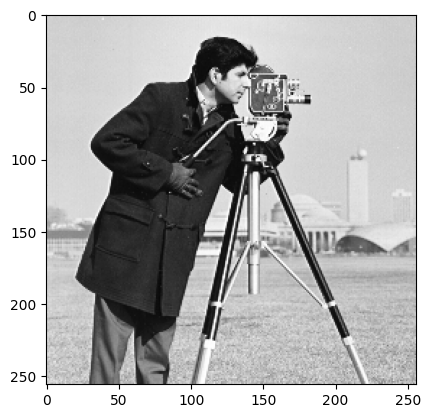

In [89]:
imagem1 = cv2.imread('dataset/baboon.pgm', cv2.IMREAD_GRAYSCALE)
imagem2 = cv2.imread('dataset/monarch.pgm', cv2.IMREAD_GRAYSCALE)
imagem3 = cv2.imread('dataset/peppers.pgm', cv2.IMREAD_GRAYSCALE)
imagem4 = cv2.imread('dataset/wedge.pgm', cv2.IMREAD_GRAYSCALE)
imagem5 = cv2.imread('dataset/airplane.pgm', cv2.IMREAD_GRAYSCALE)
imagem6 = cv2.imread('dataset/cameraman.pgm', cv2.IMREAD_GRAYSCALE)
imagem7 = cv2.imread('dataset/coins.png', cv2.IMREAD_GRAYSCALE)

imagem = imagem6
nome = 'cameraman'

plt.imshow(imagem, cmap='gray')

In [ ]:
def transformada_fourier(imagem, nome):
    img_float = imagem.astype(np.float64) / 255.0

    espectro = np.fft.fft2(img_float)

    espectro_shift = np.fft.fftshift(espectro)

    espectro_magnitude = np.abs(espectro_shift)

    espectro_log = cv2.log(espectro_magnitude + 1)

    espectro_normalizado = cv2.normalize(espectro_log, None, 0, 255, cv2.NORM_MINMAX)

    espectro_colorido = cv2.applyColorMap(espectro_normalizado.astype(np.uint8), cv2.COLORMAP_INFERNO)
    espectro_colorido_rgb = cv2.cvtColor(espectro_colorido, cv2.COLOR_BGR2RGB)

    #-------------------------------------------------------------------#

    # Configurando uma figura com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Plotando as imagens em suas respectivas posições (índices de 0 a 3)
    axes[0].imshow(espectro_magnitude, cmap='gray')
    axes[0].set_title('Magnitude Crua')
    axes[0].axis('off') # Remove os eixos numéricos para ficar mais limpo

    axes[1].imshow(espectro_log, cmap='gray')
    axes[1].set_title('Escala Log')
    axes[1].axis('off')

    axes[2].imshow(espectro_normalizado, cmap='gray')
    axes[2].set_title('Normalizado (0-255)')
    axes[2].axis('off')

    plt.tight_layout() # Ajusta os espaçamentos
    plt.show() # Mostra o painel inteiro de uma vez só

    plt.imshow(espectro_colorido_rgb)

    # A função imsave funciona de forma independente da tela
    plt.imsave(f'resultados/espectro_{nome}.png', espectro_colorido_rgb)

    return espectro_log

Criação do Histograma:

In [ ]:
def criacao_histograma_angular(espectro_shift, nome, raio_threshold=30):

    linhas, colunas = espectro_shift.shape

    cy, cx = linhas // 2, colunas // 2

    matriz_y, matriz_x = np.indices((linhas, colunas))

    x_rel = matriz_x - cx
    y_rel = cy - matriz_y

    matriz_angulos = np.arctan2(y_rel, x_rel)

    raio = np.sqrt(x_rel**2 + y_rel**2)

    mask = raio >= raio_threshold

    angulos_validos = matriz_angulos[mask]

    magnitudes = np.abs(espectro_shift)[mask]

    n_bins = 72

    histograma, intervalos = np.histogram(
        angulos_validos,
        bins=n_bins,
        range=(-np.pi, np.pi),
        weights=magnitudes
    )

    # Configurações do gráfico idênticas às do seu amigo
    plt.figure(figsize=(8, 5))
    
    # Linha contínua azul (#457b9d) em vez de gráfico de barras
    plt.plot(histograma, color='#457b9d', linewidth=2)
    
    plt.title('histograma angular', fontsize=14)
    plt.xlabel('bin angular', fontsize=12)
    plt.ylabel('energia', fontsize=12)
    
    # Limita o eixo X para ir de 0 a 35 (se n_bins = 36)
    plt.xlim([0, len(histograma) - 1])
    
    plt.tight_layout()
    plt.savefig(f'resultados/histograma_angular_{nome}.png')
    plt.show()
    plt.close()

    # Orientações dominantes
    indices_picos = np.argsort(histograma)[-4:][::-1]
    print(f"--- Orientações Dominantes para a imagem {nome} ---")
    for i, idx in enumerate(indices_picos):
        graus_inf = np.degrees(intervalos[idx])
        graus_sup = np.degrees(intervalos[idx + 1])
        print(f"{i+1}º Pico (Bin {idx}): Entre {graus_inf:.1f}° e {graus_sup:.1f}° | Energia: {histograma[idx]:.2f}")


Testes e Exemplos:

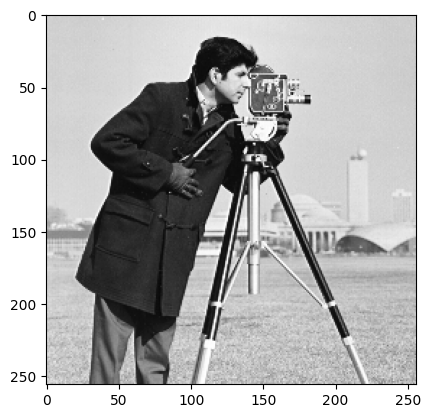

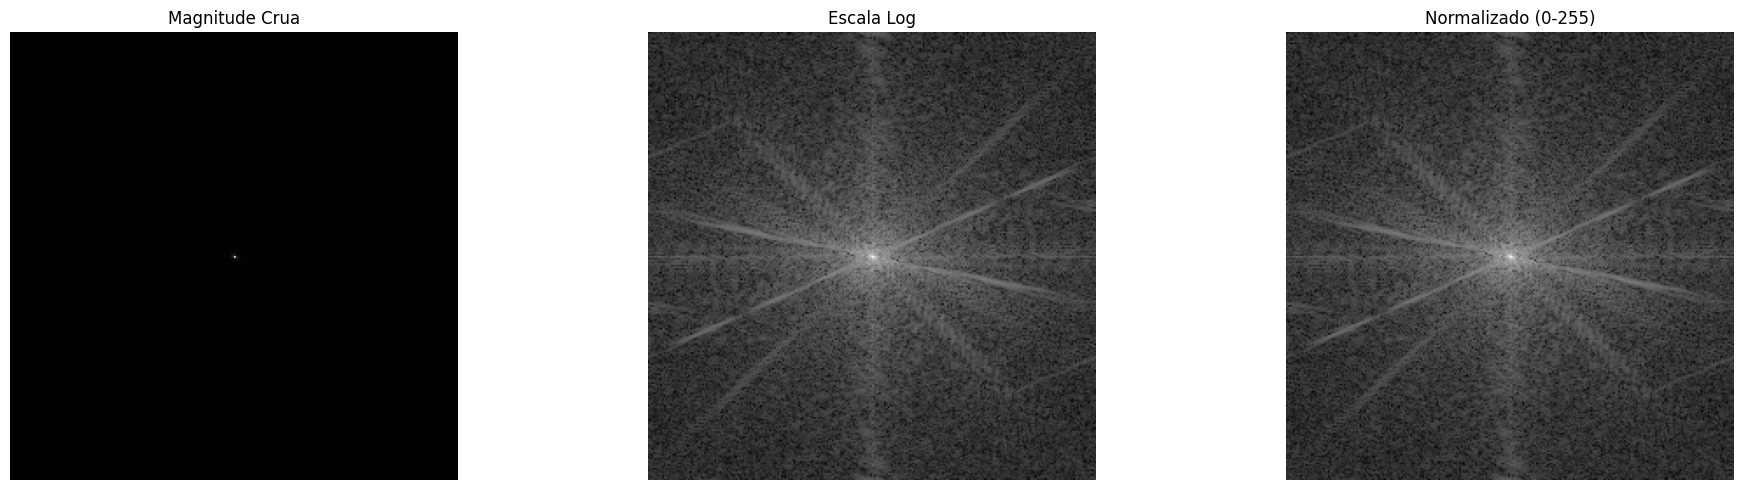

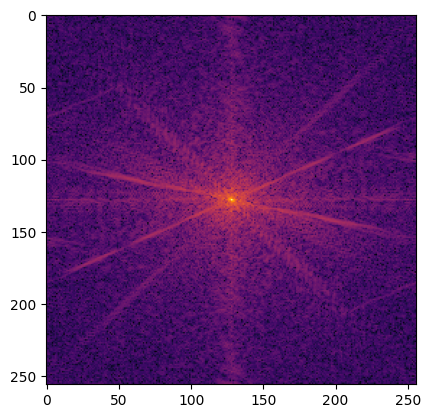

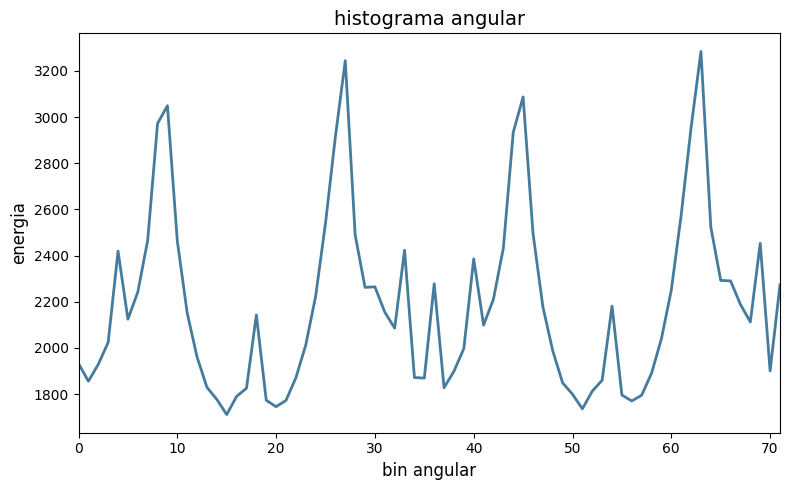

--- Orientações Dominantes para a imagem cameraman ---
1º Pico (Bin 63): Entre 135.0° e 140.0° | Energia: 3283.82
2º Pico (Bin 27): Entre -45.0° e -40.0° | Energia: 3244.17
3º Pico (Bin 45): Entre 45.0° e 50.0° | Energia: 3087.25
4º Pico (Bin 9): Entre -135.0° e -130.0° | Energia: 3048.89


In [104]:
#Imagem normal

plt.imshow(imagem, cmap='gray')   

espectro_log = transformada_fourier(imagem, nome)

criacao_histograma_angular(espectro_log, nome)

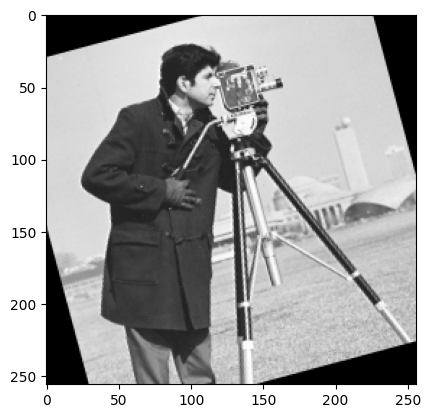

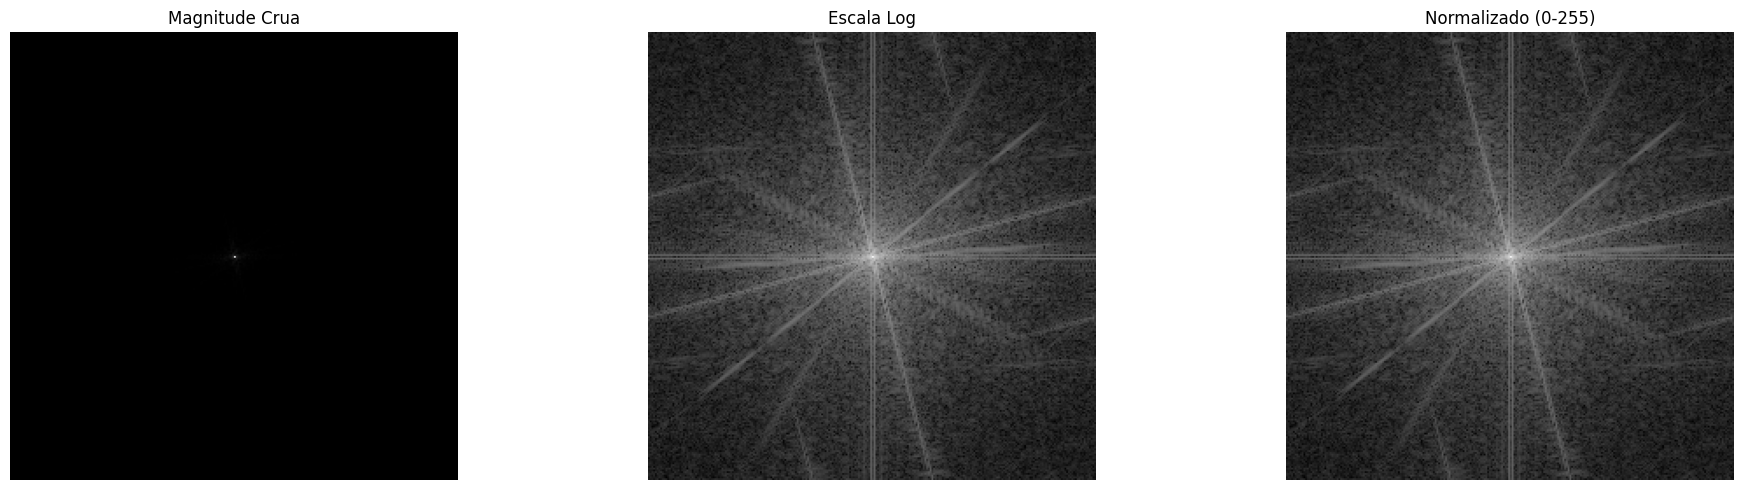

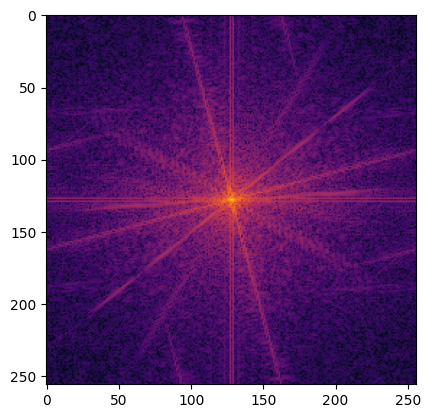

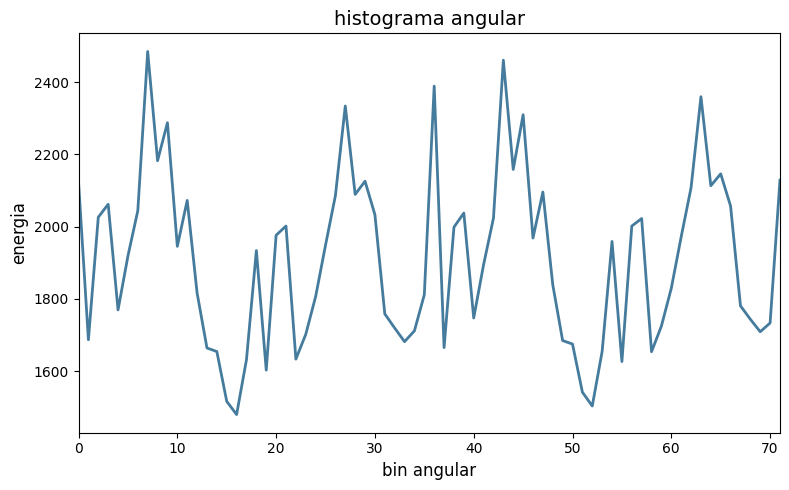

--- Orientações Dominantes para a imagem cameraman_rotacionada ---
1º Pico (Bin 7): Entre -145.0° e -140.0° | Energia: 2484.74
2º Pico (Bin 43): Entre 35.0° e 40.0° | Energia: 2460.68
3º Pico (Bin 36): Entre 0.0° e 5.0° | Energia: 2388.90
4º Pico (Bin 63): Entre 135.0° e 140.0° | Energia: 2359.67


In [105]:
#Imagem Rotacionada


altura, largura = imagem.shape[:2]
centro = (largura // 2, altura // 2)
angulo = 15
escala = 1.0

matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, escala)

#imagem_normalizada =  imagem.astype(np.float32) / 255.0

imagem_rotacionada = cv2.warpAffine(imagem, matriz_rotacao, (largura, altura))

#imagem_rotacionada = cv2.rotate(imagem, cv2.ROTATE_90_CLOCKWISE)

plt.imshow(imagem_rotacionada, cmap='gray')
plt.imsave(f'resultados/imagem_rotacionada_{nome}.png', imagem_rotacionada, cmap='gray')
espectro_log = transformada_fourier(imagem_rotacionada, nome + '_rotacionada')
criacao_histograma_angular(espectro_log, nome + '_rotacionada')


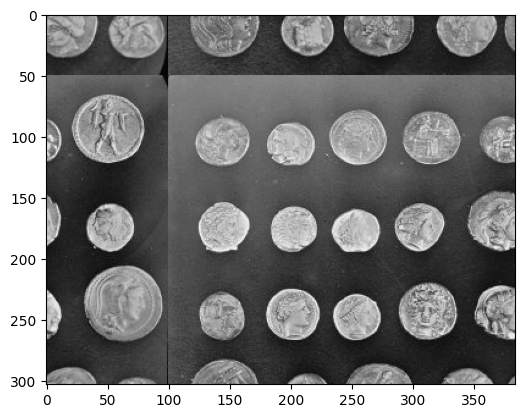

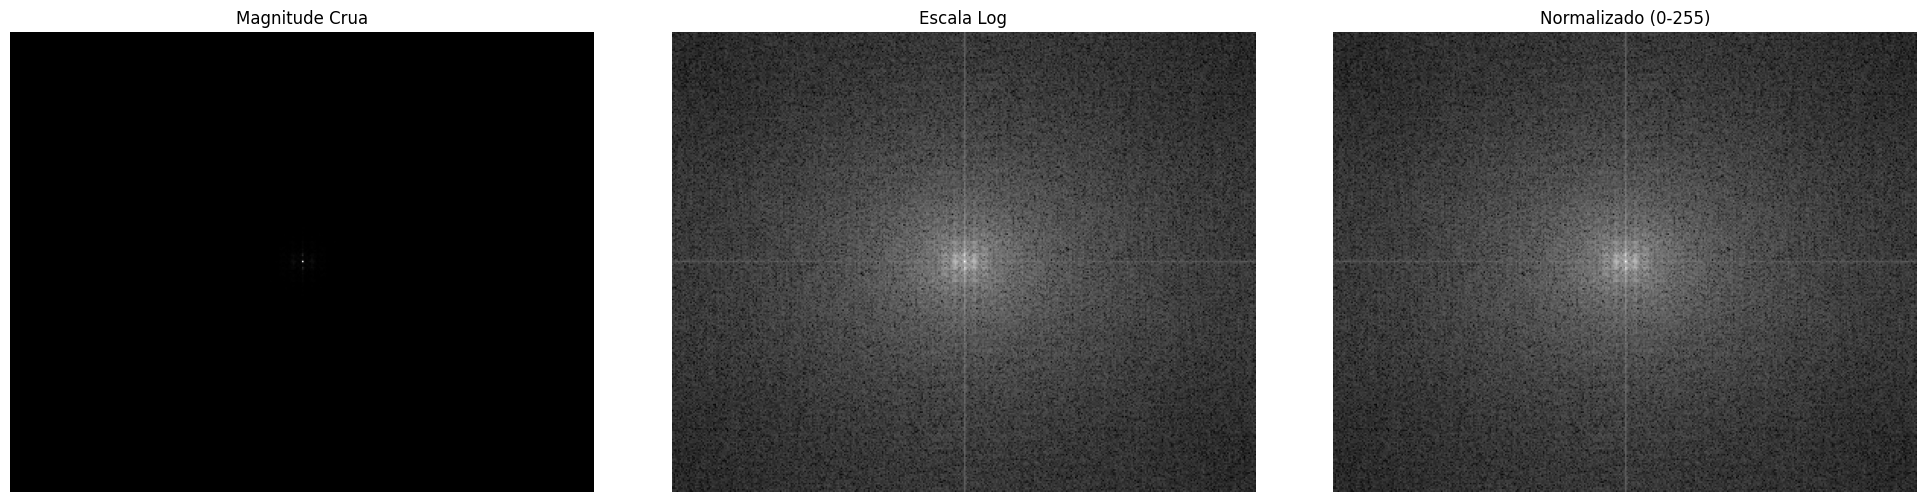

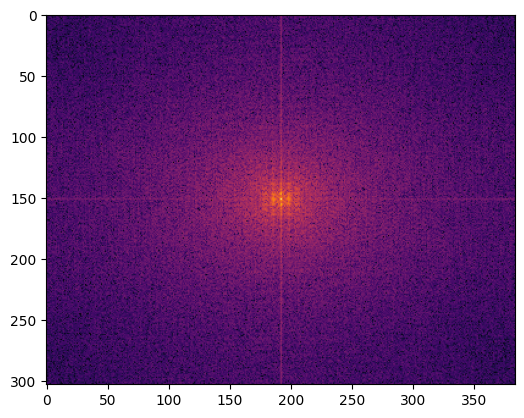

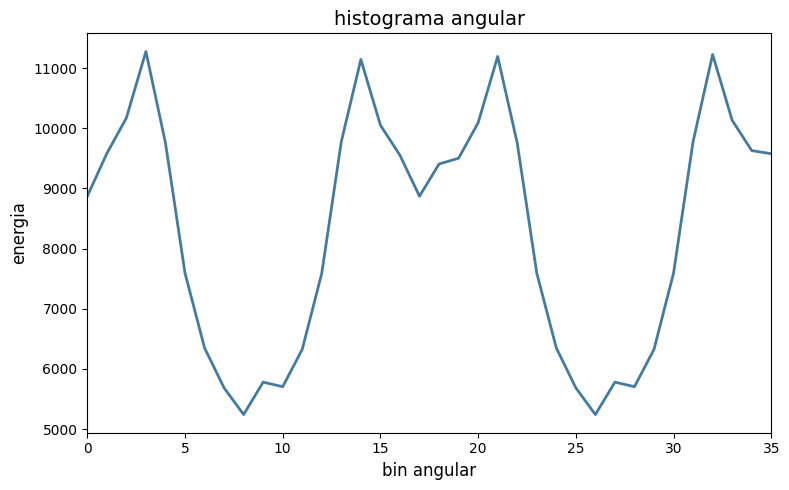

--- Orientações Dominantes para a imagem coins_transladada ---
1º Pico (Bin 3): Entre -150.0° e -140.0° | Energia: 11275.51
2º Pico (Bin 32): Entre 140.0° e 150.0° | Energia: 11225.14
3º Pico (Bin 21): Entre 30.0° e 40.0° | Energia: 11193.45
4º Pico (Bin 14): Entre -40.0° e -30.0° | Energia: 11143.09


In [86]:
#Imagem Transladada

deslocamento_x = 100  # Positivo move para a direita, negativo para a esquerda
deslocamento_y = 50   # Positivo move para baixo, negativo para cima

imagem_transladada = np.roll(imagem, shift=deslocamento_x, axis=1)
imagem_transladada = np.roll(imagem_transladada, shift=deslocamento_y, axis=0)

plt.imshow(imagem_transladada, cmap='gray')
plt.imsave(f'resultados/imagem_transladada_{nome}.png', imagem_transladada, cmap='gray')
espectro_log_transladado = transformada_fourier(imagem_transladada, nome + '_transladada')
criacao_histograma_angular(espectro_log_transladado, nome + '_transladada')


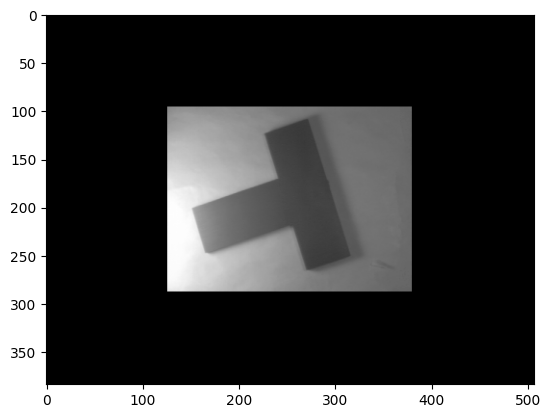

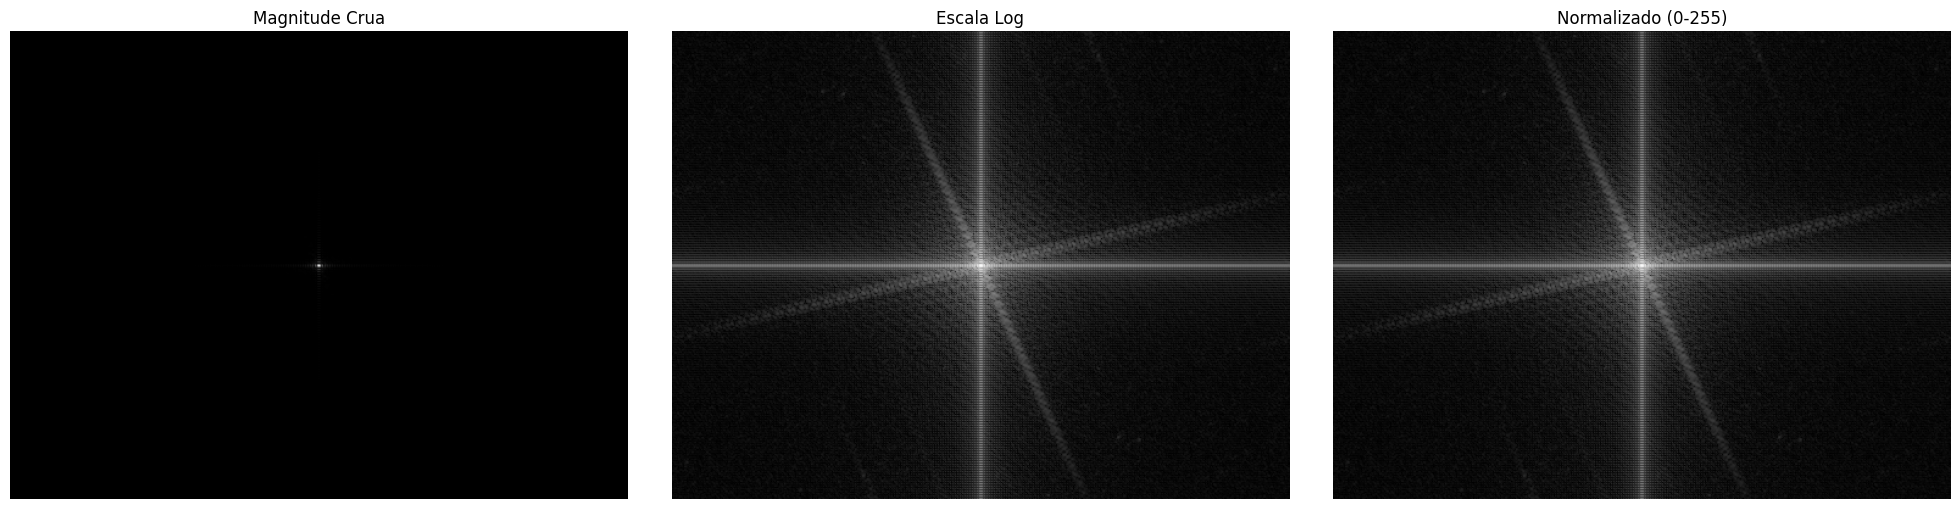

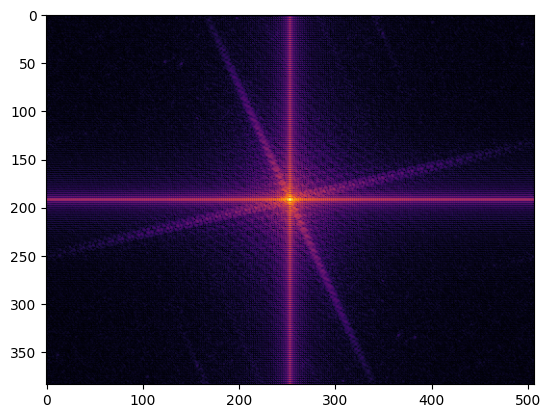

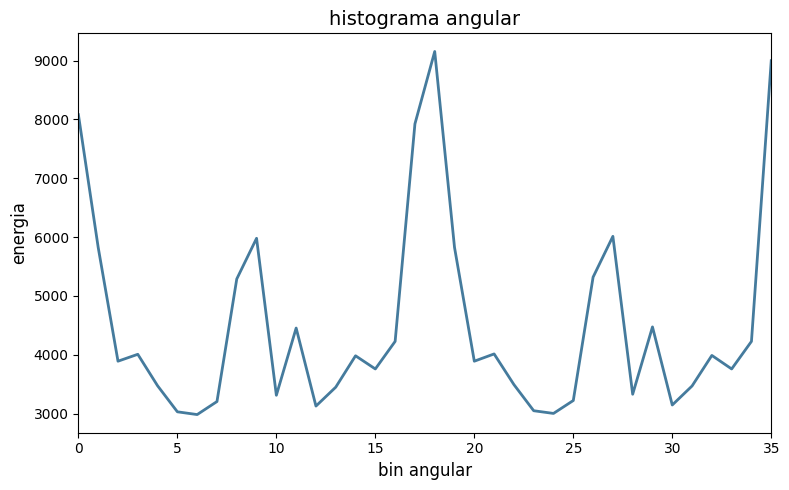

--- Orientações Dominantes para a imagem wedge_escalada ---
1º Pico (Bin 18): Entre 0.0° e 10.0° | Energia: 9156.02
2º Pico (Bin 35): Entre 170.0° e 180.0° | Energia: 8999.12
3º Pico (Bin 0): Entre -180.0° e -170.0° | Energia: 8082.11
4º Pico (Bin 17): Entre -10.0° e 0.0° | Energia: 7925.21


In [82]:
#Imagem Escalada

imagem_escalada_pequena = cv2.resize(imagem, None, fx=0.5, fy=0.5)
imagem_escalada = np.zeros_like(imagem)  # canvas do tamanho original
h, w = imagem_escalada_pequena.shape
oy, ox = (imagem.shape[0] - h) // 2, (imagem.shape[1] - w) // 2
imagem_escalada[oy:oy+h, ox:ox+w] = imagem_escalada_pequena
plt.imshow(imagem_escalada, cmap='gray')
plt.imsave(f'resultados/imagem_escalada_{nome}.png', imagem_escalada, cmap='gray')

espectro_log_escalado = transformada_fourier(imagem_escalada, nome + '_escalada')
criacao_histograma_angular(espectro_log_escalado, nome + '_escalada')
